In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torch.backends.cudnn as cudnn
cudnn.benchmark = True

torch.manual_seed(42)

In [28]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super(PrunableLinear, self).__init__()
        self.weight = nn.Parameter(torch.nn.init.kaiming_uniform_(
            torch.empty(out_features, in_features)))
        self.bias = nn.Parameter(torch.zeros(out_features))
        # Initialize slightly positive so weights start active
        self.gate_scores = nn.Parameter(torch.ones(out_features, in_features) * 2.0)

    def forward(self, x):
        # We multiply the weight by the sigmoid of the gate score
        gates = torch.sigmoid(self.gate_scores)
        pruned_weights = self.weight * gates
        return nn.functional.linear(x, pruned_weights, self.bias)

    def get_gates(self):
        return torch.sigmoid(self.gate_scores)

In [29]:
class SelfPruningNet(nn.Module):
    def __init__(self, input_dim=3072): # 32*32*3
        super(SelfPruningNet, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = PrunableLinear(input_dim, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

    def sparsity_loss(self):
        total = 0
        for module in self.modules():
            if isinstance(module, PrunableLinear):
                # Using L1 penalty on the gate values to push them toward 0
                gates = module.get_gates()
                total += torch.sum(gates)
        return total

In [30]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2)

In [31]:
def train(model, optimizer, criterion, loader, lambda_sparse, device):
    model.train()
    total_loss = 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        cls_loss = criterion(outputs, labels)
        sp_loss = model.sparsity_loss()
        loss = cls_loss + lambda_sparse * sp_loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

In [32]:
def evaluate(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    return 100 * correct / total

def sparsity_level(model, threshold=1e-2):
    total_params = 0
    pruned_params = 0
    model.eval()
    with torch.no_grad():
        for module in model.modules():
            if isinstance(module, PrunableLinear):
                gates = module.get_gates()
                total_params += gates.numel()
                pruned_params += (gates < threshold).sum().item()
    return 100 * pruned_params / total_params

In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()
lambdas = [1e-6, 5e-6, 1e-5]
results = []

EPOCHS = 60
WARMUP = 8

for lam in lambdas:
    print(f"\nTraining with lambda = {lam}")
    model = SelfPruningNet().to(device)

    weight_params = [p for n, p in model.named_parameters() if 'gate' not in n]
    gate_params   = [p for n, p in model.named_parameters() if 'gate' in n]

    optimizer = optim.Adam([
        {'params': weight_params, 'lr': 1e-3},
        {'params': gate_params,   'lr': 5e-3}
    ])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0
        effective_lam = 0.0 if epoch < WARMUP else lam

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            cls_loss = criterion(outputs, labels)
            sp_loss  = model.sparsity_loss()
            loss = cls_loss + effective_lam * sp_loss
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        scheduler.step()
        if (epoch + 1) % 5 == 0:
            eff = f"{effective_lam:.0e}" if effective_lam > 0 else "warmup"
            print(f"  Epoch {epoch+1}/{EPOCHS} | Loss: {total_loss/len(train_loader):.4f} | λ={eff}")

    acc      = evaluate(model, test_loader, device)
    sparsity = sparsity_level(model)
    print(f"  Test Accuracy: {acc:.2f}% | Sparsity: {sparsity:.2f}%")
    results.append({"lambda": lam, "accuracy": acc, "sparsity": sparsity, "model": model})


Training with lambda = 1e-06
  Epoch 5/60 | Loss: 1.1147 | λ=warmup
  Epoch 10/60 | Loss: 2.1005 | λ=1e-06
  Epoch 15/60 | Loss: 1.4838 | λ=1e-06
  Epoch 20/60 | Loss: 1.1518 | λ=1e-06
  Epoch 25/60 | Loss: 0.9669 | λ=1e-06
  Epoch 30/60 | Loss: 0.8552 | λ=1e-06
  Epoch 35/60 | Loss: 0.7682 | λ=1e-06
  Epoch 40/60 | Loss: 0.7066 | λ=1e-06
  Epoch 45/60 | Loss: 0.6561 | λ=1e-06
  Epoch 50/60 | Loss: 0.6015 | λ=1e-06
  Epoch 55/60 | Loss: 0.5619 | λ=1e-06
  Epoch 60/60 | Loss: 0.5512 | λ=1e-06
  Test Accuracy: 54.94% | Sparsity: 21.62%

Training with lambda = 5e-06
  Epoch 5/60 | Loss: 1.1180 | λ=warmup
  Epoch 10/60 | Loss: 6.0342 | λ=5e-06
  Epoch 15/60 | Loss: 3.1135 | λ=5e-06
  Epoch 20/60 | Loss: 2.1538 | λ=5e-06
  Epoch 25/60 | Loss: 1.6398 | λ=5e-06
  Epoch 30/60 | Loss: 1.2934 | λ=5e-06
  Epoch 35/60 | Loss: 1.0318 | λ=5e-06
  Epoch 40/60 | Loss: 0.8385 | λ=5e-06
  Epoch 45/60 | Loss: 0.7123 | λ=5e-06
  Epoch 50/60 | Loss: 0.6415 | λ=5e-06
  Epoch 55/60 | Loss: 0.6108 | λ=5e-06


In [34]:
print(f"\n{'Lambda':<12} {'Test Accuracy (%)':<22} {'Sparsity Level (%)'}")
print("-" * 55)
for r in results:
    print(f"{r['lambda']:<12} {r['accuracy']:<22.2f} {r['sparsity']:.2f}")


Lambda       Test Accuracy (%)      Sparsity Level (%)
-------------------------------------------------------
1e-06        54.94                  21.62
5e-06        54.73                  63.85
1e-05        54.01                  75.40


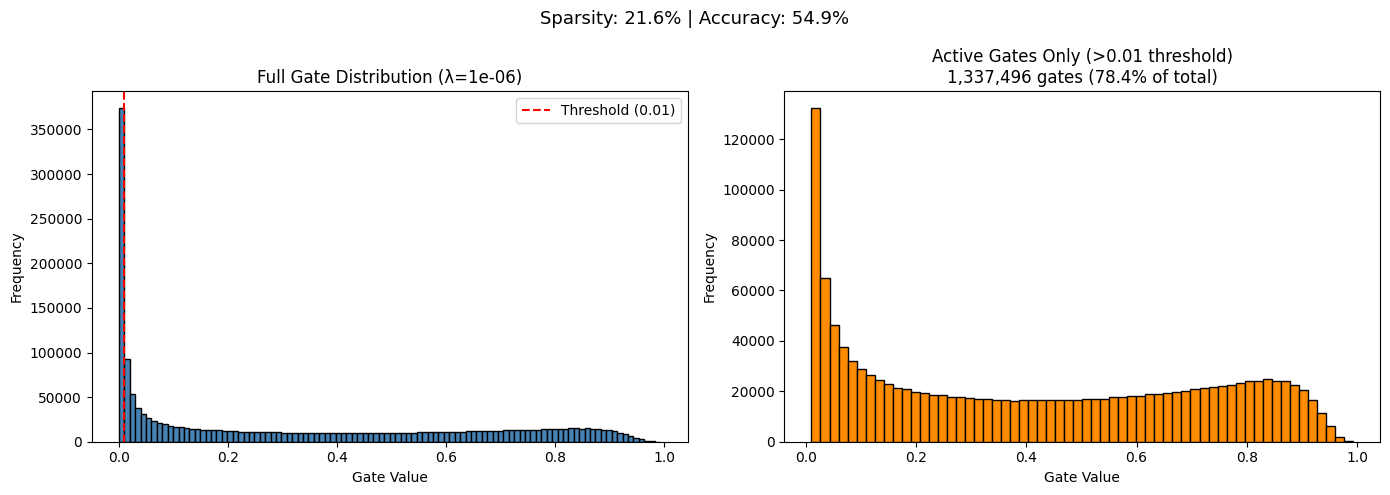


Gate Statistics:
  Total gates:    1,706,496
  Pruned (<0.01): 369,000 (21.6%)
  Active (>=0.01): 1,337,496 (78.4%)
  Mean gate value: 0.3223
  Max gate value:  0.9927


In [35]:
best = max(results, key=lambda r: r['accuracy'])
best_model = best['model']

all_gates = []
for module in best_model.modules():
    if isinstance(module, PrunableLinear):
        gates = module.get_gates().detach().cpu().numpy().flatten()
        all_gates.extend(gates)

all_gates = np.array(all_gates)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(all_gates, bins=100, color='steelblue', edgecolor='black')
axes[0].axvline(x=0.01, color='red', linestyle='--', label='Threshold (0.01)')
axes[0].set_xlabel("Gate Value")
axes[0].set_ylabel("Frequency")
axes[0].set_title(f"Full Gate Distribution (λ={best['lambda']})")
axes[0].legend()

active_gates = all_gates[all_gates >= 0.01]
axes[1].hist(active_gates, bins=60, color='darkorange', edgecolor='black')
axes[1].set_xlabel("Gate Value")
axes[1].set_ylabel("Frequency")
axes[1].set_title(f"Active Gates Only (>{0.01} threshold)\n{len(active_gates):,} gates ({100*len(active_gates)/len(all_gates):.1f}% of total)")

plt.suptitle(f"Sparsity: {best['sparsity']:.1f}% | Accuracy: {best['accuracy']:.1f}%", fontsize=13)
plt.tight_layout()
plt.savefig("gate_distribution.png", dpi=150)
plt.show()

print(f"\nGate Statistics:")
print(f"  Total gates:    {len(all_gates):,}")
print(f"  Pruned (<0.01): {(all_gates < 0.01).sum():,} ({100*(all_gates<0.01).mean():.1f}%)")
print(f"  Active (>=0.01): {(all_gates >= 0.01).sum():,} ({100*(all_gates>=0.01).mean():.1f}%)")
print(f"  Mean gate value: {all_gates.mean():.4f}")
print(f"  Max gate value:  {all_gates.max():.4f}")